## Setup and Imports
Install required libraries and import dependencies for training the DQN agent.

In [2]:
!pip install --upgrade pip
!pip install gymnasium[atari,accept-rom-license]
!pip install ale-py
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import ale_py
import cv2
from collections import deque
import random
import matplotlib.pyplot as plt


In [3]:
print("ALE version:", ale_py.__version__)
print("Gym version:", gym.__version__)

ALE version: 0.11.2
Gym version: 1.2.3


## Frame Preprocessing and Stacking
Preprocess raw game frames by converting to grayscale, resizing, and stacking frames to provide temporal context.

In [4]:
class FrameStacker:
    def __init__(self, k):
        self.k = k
        self.frames = deque(maxlen=k)

    def preprocess(self, frame):
        frame = np.array(frame)

        if frame.ndim == 3:
            frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)

        frame = cv2.resize(frame, (64, 64))
        frame = frame.astype(np.float16) / 255.0
        return frame

    def reset(self, obs):
        frame = self.preprocess(obs)
        self.frames.clear()
        for _ in range(self.k):
            self.frames.append(frame)
        return np.stack(self.frames, axis=0)

    def step(self, obs):
        frame = self.preprocess(obs)
        self.frames.append(frame)
        return np.stack(self.frames, axis=0)

## Deep Q-Network (DQN)
Define the convolutional neural network used to approximate Q-values.

In [5]:
class DQN(nn.Module):
    def __init__(self, input_channels, num_actions):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, 8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1),
            nn.ReLU()
        )
        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, 64, 64)
            conv_out = self.conv(dummy)
            self.flatten_size = conv_out.view(1, -1).shape[1]

        self.fc = nn.Sequential(
            nn.Linear(self.flatten_size, 512),
            nn.ReLU(),
            nn.Linear(512, num_actions)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)
        return self.fc(x)

## Replay Buffer
Store and sample past experiences to stabilize training.

In [6]:
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)
        return (
          torch.from_numpy(np.array(s)).float(),
          torch.tensor(a),
          torch.tensor(r, dtype=torch.float32),
          torch.from_numpy(np.array(ns)).float(),
          torch.tensor(d, dtype=torch.float32)
)

    def __len__(self):
        return len(self.buffer)


## DQN Agent
Implement action selection, learning, and target network updates.

In [7]:
class Agent:
    def __init__(self, input_channels, num_actions, device):
        self.device = device
        self.num_actions = num_actions
        self.q = DQN(input_channels, num_actions).to(device)
        self.target = DQN(input_channels, num_actions).to(device)
        self.target.load_state_dict(self.q.state_dict())

        self.optim = optim.Adam(self.q.parameters(), lr=1e-4)
        self.buffer = ReplayBuffer()
        self.gamma = 0.99
        self.batch_size = 16
        self.update_every = 1000
        self.step_count = 0

    def act(self, state, eps):
        if random.random() < eps:
            return random.randrange(self.num_actions)

        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return self.q(state).argmax(1).item()

    def learn(self):
        if len(self.buffer) < self.batch_size:
            return None

        s, a, r, ns, d = self.buffer.sample(self.batch_size)
        s, ns = s.to(self.device), ns.to(self.device)
        a, r, d = a.to(self.device), r.to(self.device), d.to(self.device)

        q_vals = self.q(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            target_q = self.target(ns).max(1)[0]
            y = r + self.gamma * target_q * (1 - d)

        loss = nn.SmoothL1Loss()(q_vals, y)
        self.optim.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q.parameters(), 10)
        self.optim.step()

        self.step_count += 1
        if self.step_count % self.update_every == 0:
            self.target.load_state_dict(self.q.state_dict())

        return loss.item()


## Training Function
Train the DQN agent using epsilon-greedy exploration.

In [8]:
def train_dqn(stack_size, episodes=7):
    env = gym.make(
    "ALE/MsPacman-v5",
    obs_type="rgb",
    frameskip=2,
    repeat_action_probability=0.0
)
    num_actions = env.action_space.n
    stacker = FrameStacker(k=stack_size)
    agent = Agent(stack_size, num_actions, device)

    rewards = []

    eps = 1.0
    for ep in range(episodes):
        obs, _ = env.reset()
        state = stacker.reset(obs)
        total = 0
        done = False

        while not done:
            action = agent.act(state, eps)
            obs, reward, term, trunc, _ = env.step(action)
            reward = np.sign(reward)
            done = term or trunc

            next_state = stacker.step(obs)
            agent.buffer.push(state, action, reward, next_state, done)
            if len(agent.buffer) > 500 and agent.step_count % 4 == 0:
                agent.learn()

            state = next_state
            total += reward

        eps = max(0.05, eps - 0.002)
        rewards.append(total)

        print(f"Stack={stack_size} | Episode {ep+1} | Score {total}")

    env.close()
    return rewards


## Ablation Study Setup
Compare performance with and without frame stacking while keeping all other components fixed.

In [9]:
def run_experiment(stack_size, seeds=[0, 1], episodes=20):
    all_runs = []

    for seed in seeds:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        rewards = train_dqn(stack_size=stack_size, episodes=episodes)
        all_runs.append(rewards)

    return np.array(all_runs)

## Running Experiments
Train the agent under both configurations and collect rewards.

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

runs_no_stack = run_experiment(stack_size=1, seeds=[0,1], episodes=50)
runs_stack_4 = run_experiment(stack_size=4, seeds=[0,1], episodes=50)

avg_no = runs_no_stack.mean(axis=0)
avg_stack = runs_stack_4.mean(axis=0)


Stack=1 | Episode 1 | Score 18.0
Stack=1 | Episode 2 | Score 14.0
Stack=1 | Episode 3 | Score 10.0
Stack=1 | Episode 4 | Score 13.0
Stack=1 | Episode 5 | Score 13.0
Stack=1 | Episode 6 | Score 17.0
Stack=1 | Episode 7 | Score 17.0
Stack=1 | Episode 8 | Score 21.0
Stack=1 | Episode 9 | Score 18.0
Stack=1 | Episode 10 | Score 20.0
Stack=1 | Episode 11 | Score 16.0
Stack=1 | Episode 12 | Score 14.0
Stack=1 | Episode 13 | Score 28.0
Stack=1 | Episode 14 | Score 21.0
Stack=1 | Episode 15 | Score 16.0
Stack=1 | Episode 16 | Score 15.0
Stack=1 | Episode 17 | Score 28.0
Stack=1 | Episode 18 | Score 14.0
Stack=1 | Episode 19 | Score 12.0
Stack=1 | Episode 20 | Score 21.0
Stack=1 | Episode 21 | Score 18.0
Stack=1 | Episode 22 | Score 12.0
Stack=1 | Episode 23 | Score 14.0
Stack=1 | Episode 24 | Score 13.0
Stack=1 | Episode 25 | Score 13.0
Stack=1 | Episode 26 | Score 23.0
Stack=1 | Episode 27 | Score 16.0
Stack=1 | Episode 28 | Score 14.0
Stack=1 | Episode 29 | Score 19.0
Stack=1 | Episode 30 | 

## Results Aggregation
Average rewards across multiple runs to reduce variance and improve reliability.

In [22]:
def moving_average(x, window):
    if len(x) < window:
        return np.array(x)
    return np.convolve(x, np.ones(window)/window, mode="valid")

In [23]:
np.save("avg_no.npy", avg_no)
np.save("avg_stack.npy", avg_stack)

## Results Summary
Report mean, standard deviation, and maximum reward for each configuration.

In [24]:
def summarize(scores, label):
    print(
        f"{label}: Mean={np.mean(scores):.2f}, Std={np.std(scores):.2f}, Max={np.max(scores):.2f}"
    )

print("=== Ablation Results ===")
summarize(avg_no, "No Frame Stacking")
summarize(avg_stack, "4-Frame Stacking")

print(f"\nImprovement (Stack 4 - No Stack): {avg_stack.mean() - avg_no.mean():.2f}")

=== Ablation Results ===
No Frame Stacking: Mean=17.45, Std=3.70, Max=26.50
4-Frame Stacking: Mean=18.32, Std=3.56, Max=25.50

Improvement (Stack 4 - No Stack): 0.87


## Raw Reward Plot
Visualize episode rewards for both configurations.

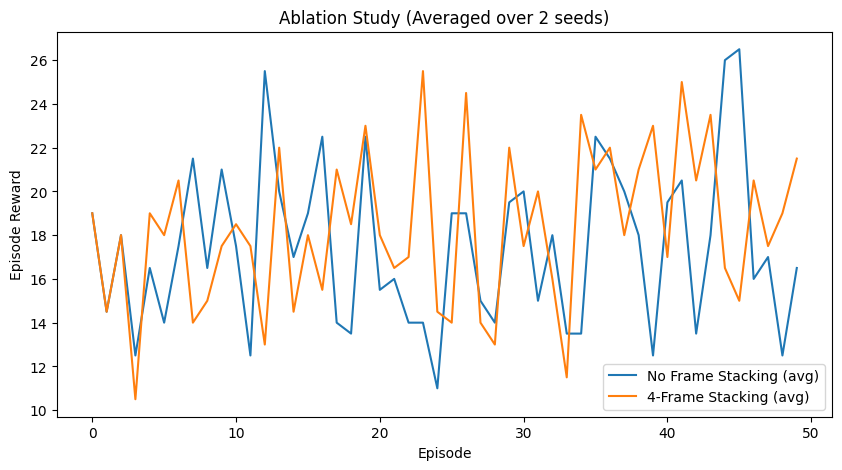

In [25]:
plt.figure(figsize=(10,5))
plt.plot(avg_no, label="No Frame Stacking (avg)")
plt.plot(avg_stack, label="4-Frame Stacking (avg)")
plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.legend()
plt.title("Ablation Study (Averaged over 2 seeds)")

plt.savefig("avg_rewards.png")  # optional
plt.show()

## Smoothed Reward Plot
Apply a moving average to highlight learning trends and reduce noise.

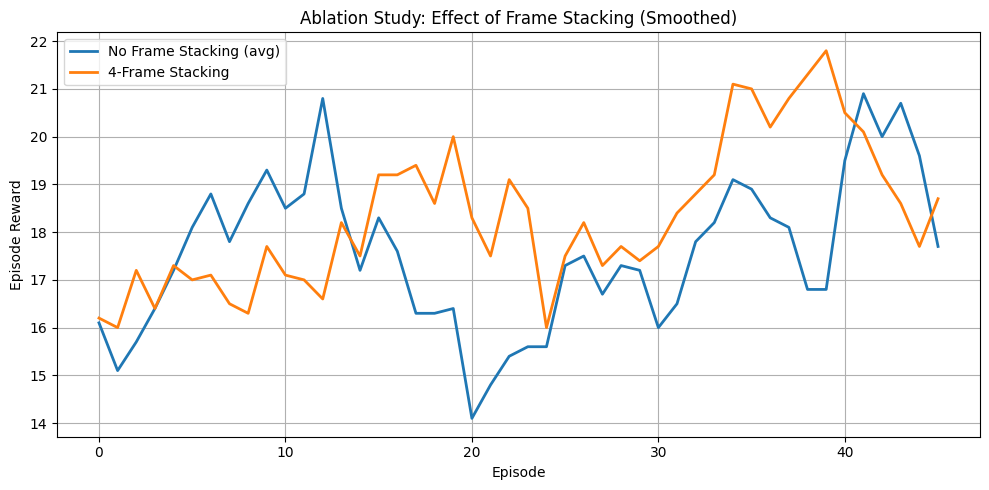

In [26]:
window = 5

ma_no = moving_average(avg_no, window)
ma_stack = moving_average(avg_stack, window)

plt.figure(figsize=(10, 5))
plt.plot(ma_no, label="No Frame Stacking (avg)", linewidth=2)
plt.plot(ma_stack, label="4-Frame Stacking", linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Episode Reward")
plt.title("Ablation Study: Effect of Frame Stacking (Smoothed)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("smoothed_rewards.png")plt.show()

## Download Results
Save and download plots for analysis and reporting.

In [27]:
from google.colab import files

files.download("avg_rewards.png")
files.download("smoothed_rewards.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Ablation Study Conclusion

I conducted an ablation study by removing frame stacking while keeping the DQN architecture and training parameters fixed. The results show that using 4-frame stacking leads to a modest improvement in performance compared to a single frame. The stacked model achieves a slightly higher average reward (18.32 vs 17.45) and exhibits more stable learning behavior over time, with a small reduction in variance (3.56 vs 3.70).

While the improvement is not large (approximately +0.87 in average reward), the smoothed reward curves indicate that frame stacking helps the agent better capture temporal information, such as object movement, which supports more consistent decision-making. The relatively small gap between the two configurations is likely due to the limited training duration and reduced model capacity.